# Forgewright — EDA: Tool Wear Detection (v2)

Restructured analysis, in this order: first the relationship between `vibration_peak_mean`
and `vibration_rms_mean`, then the relationship between `vibration_peak_mean` and
`power_kw_mean` (finding and fixing outliers), checking dependence on `part_type`/
`machine_id`, and finally the `wear_residual` dynamics over time for each machine.

## 0. Load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

power = pd.read_csv('~/projects/forgewright/data/power.csv')
vibration = pd.read_csv('~/projects/forgewright/data/vibration.csv')
log = pd.read_csv('~/projects/forgewright/data/production_log.csv')

power['timestamp'] = pd.to_datetime(power['timestamp'])
vibration['timestamp'] = pd.to_datetime(vibration['timestamp'])
log['start_time'] = pd.to_datetime(log['start_time'])
log['end_time'] = pd.to_datetime(log['end_time'])

## 0.1 Data cleaning: rows with `end_time <= start_time`

In [2]:
print('Jobs with start_time >= end_time:')
print(log[log['start_time'] >= log['end_time']]['job_id'].tolist())
log = log[log['start_time'] < log['end_time']].reset_index(drop=True)

Jobs with start_time >= end_time:
['JOB-045', 'JOB-116', 'JOB-220']


## 0.2 Time synchronization: log in local time, sensors in UTC

`start_time`/`end_time` in the log are naive timestamps with no explicit timezone, while
`power`/`vibration` are marked in UTC. Instead of assuming a specific timezone (which
wouldn't generalize to a held-out shift), we search for the whole-hour offset that
maximizes the number of jobs whose window falls inside that machine's actual sensor
recording range.

In [3]:
def infer_utc_offset_hours(log, power, vibration, candidate_hours=range(-14, 15)):
    """
    log['start_time']/['end_time'] are naive local timestamps; power/vibration
    timestamps are tz-aware UTC. Instead of assuming a timezone, find the whole-hour
    offset that makes the most job windows actually overlap that machine's sensor
    coverage -- this is derived from the data so it also works on a held-out shift
    where the offset might differ.
    """
    sensor_ts = pd.concat([
        power[['machine_id', 'timestamp']],
        vibration[['machine_id', 'timestamp']],
    ])
    bounds = sensor_ts.groupby('machine_id')['timestamp'].agg(['min', 'max'])
    lo = log['machine_id'].map(bounds['min'])
    hi = log['machine_id'].map(bounds['max'])

    best_hours, best_score = 0, -1
    for h in candidate_hours:
        shifted_start = (log['start_time'] + pd.Timedelta(hours=h)).dt.tz_localize('UTC')
        shifted_end = (log['end_time'] + pd.Timedelta(hours=h)).dt.tz_localize('UTC')
        score = ((shifted_start <= hi) & (shifted_end >= lo)).sum()
        if score > best_score:
            best_hours, best_score = h, score
    return best_hours, best_score


offset_hours, matched = infer_utc_offset_hours(log, power, vibration)
print(f"inferred log -> UTC offset: {offset_hours:+d}h ({matched}/{len(log)} jobs overlap sensor coverage)")

log['start_time'] = (log['start_time'] + pd.Timedelta(hours=offset_hours)).dt.tz_localize('UTC')
log['end_time'] = (log['end_time'] + pd.Timedelta(hours=offset_hours)).dt.tz_localize('UTC')

inferred log -> UTC offset: +5h (91/91 jobs overlap sensor coverage)


## 0.3 Sensor desync: gaps in vibration recording

`power` and `vibration` sample at different rates, so raw row counts can't be compared
directly. We compare the sets of unique *seconds* covered by each sensor on each machine,
and separately flag contiguous gaps (a real recording outage) rather than isolated
seconds at the window's edges (ordinary startup jitter).

In [4]:
def sensor_gaps_by_machine(power, vibration):
    """
    power/vibration sample at different rates, so raw row counts aren't comparable.
    Instead, compare the set of *unique seconds* each sensor has at least one reading
    for, per machine. Anything present in one sensor's seconds but not the other's
    is either a boundary/start-up effect (a few seconds) or a real sensor dropout
    (a sustained contiguous run) -- report both, and call out the contiguous runs.
    """
    p_sec = power.assign(sec=power['timestamp'].dt.floor('s'))
    v_sec = vibration.assign(sec=vibration['timestamp'].dt.floor('s'))

    summary = []
    gap_runs = []
    for m in sorted(set(p_sec['machine_id']) | set(v_sec['machine_id'])):
        p_set = set(p_sec.loc[p_sec['machine_id'] == m, 'sec'])
        v_set = set(v_sec.loc[v_sec['machine_id'] == m, 'sec'])
        only_power = sorted(p_set - v_set)
        only_vib = sorted(v_set - p_set)

        summary.append({
            'machine_id': m,
            'power_unique_sec': len(p_set),
            'vibration_unique_sec': len(v_set),
            'sec_missing_in_vibration': len(only_power),
            'sec_missing_in_power': len(only_vib),
        })

        run_start = run_prev = None
        for sec in only_power:
            if run_prev is not None and sec == run_prev + pd.Timedelta(seconds=1):
                run_prev = sec
                continue
            if run_start is not None:
                gap_runs.append({'machine_id': m, 'sensor': 'vibration', 'gap_start': run_start,
                                  'gap_end': run_prev, 'duration_s': (run_prev - run_start).total_seconds() + 1})
            run_start = run_prev = sec
        if run_start is not None:
            gap_runs.append({'machine_id': m, 'sensor': 'vibration', 'gap_start': run_start,
                              'gap_end': run_prev, 'duration_s': (run_prev - run_start).total_seconds() + 1})

    return pd.DataFrame(summary), pd.DataFrame(gap_runs).sort_values('duration_s', ascending=False)


sensor_sync_summary, sensor_gap_runs = sensor_gaps_by_machine(power, vibration)
display(sensor_sync_summary)
display(sensor_gap_runs)

,machine_id,power_unique_sec,vibration_unique_sec,sec_missing_in_vibration,sec_missing_in_power
0,CNC-07,28800,27622,1213,35
1,CNC-09,28800,28092,720,12
2,CNC-11,28800,28835,20,55


,machine_id,sensor,gap_start,gap_end,duration_s
1,CNC-07,vibration,2025-03-10 16:30:22+00:00,2025-03-10 16:50:22+00:00,1201.0
2,CNC-09,vibration,2025-03-10 15:00:00+00:00,2025-03-10 15:11:59+00:00,720.0
3,CNC-11,vibration,2025-03-10 13:00:00+00:00,2025-03-10 13:00:19+00:00,20.0
0,CNC-07,vibration,2025-03-10 13:00:00+00:00,2025-03-10 13:00:11+00:00,12.0


## 0.4 Filtering out jobs that fall in a vibration-sensor gap

Jobs whose window overlaps a `vibration` recording outage are dropped from the analysis —
otherwise "no data" is easy to confuse with "no vibration".

In [5]:
def jobs_without_sensor_gaps(log, gap_runs):
    """
    Drop any job whose window overlaps a known vibration-sensor dropout
    (from sensor_gap_runs) on the same machine, so tool-wear metrics aren't
    computed on partial/missing vibration data.
    """
    overlaps_gap = pd.Series(False, index=log.index)
    for _, gap in gap_runs.iterrows():
        same_machine = log['machine_id'] == gap['machine_id']
        overlap = (log['start_time'] <= gap['gap_end']) & (log['end_time'] >= gap['gap_start'])
        overlaps_gap |= same_machine & overlap

    kept = log[~overlaps_gap].reset_index(drop=True)
    dropped = log[overlaps_gap]
    return kept, dropped


log, log_dropped_for_gaps = jobs_without_sensor_gaps(log, sensor_gap_runs)
print(f"filtered out {len(log_dropped_for_gaps)} jobs overlapping a vibration sensor dropout: "
      f"{log_dropped_for_gaps['job_id'].tolist()}")
print(f"{len(log)} jobs remain in log")

filtered out 5 jobs overlapping a vibration sensor dropout: ['JOB-028', 'JOB-029', 'JOB-030', 'JOB-031', 'JOB-110']
86 jobs remain in log


## 0.5 Filtering extreme values

<Axes: >

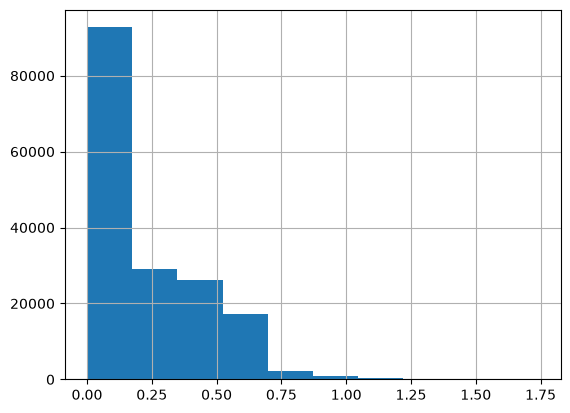

In [6]:
vibration['vibration_rms_g'].hist()

In [7]:
print(vibration['vibration_rms_g'].isnull().sum())

0


<Axes: >

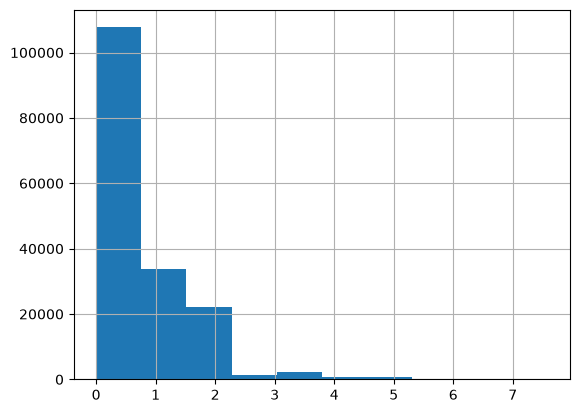

In [8]:
vibration['vibration_peak_g'].hist()

In [9]:
print(vibration['vibration_peak_g'].isnull().sum())

0


<Axes: >

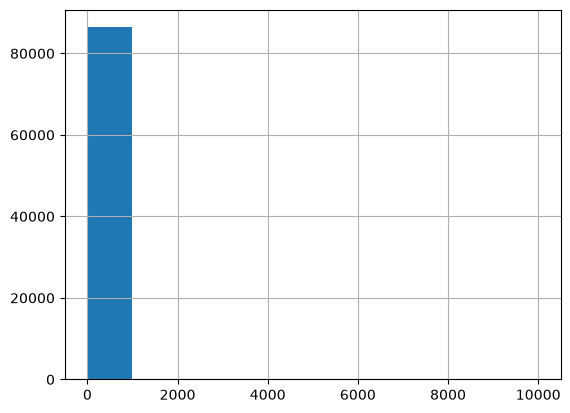

In [10]:
power['power_kw'].hist()

In [11]:
power['power_kw'].sort_values()

56286   -3.000
59602   -3.000
23011   -3.000
24780    0.290
54632    0.302
         ...  
52229      NaN
57416      NaN
59068      NaN
77156      NaN
78654      NaN
Name: power_kw, Length: 86405, dtype: float64

In [12]:
print('negative power:', len(power[power['power_kw'] < 0]))
print('outliers:', len(power[power['power_kw'] > 100]))
print('null:', len(power[power['power_kw'].isnull()]))

power = power[power['power_kw'] > 0]
power = power[power['power_kw'] < 100]
power = power[power['power_kw'].notnull()]


negative power: 3
outliers: 4
null: 16


## 0.6 Joining the log to sensor readings

In [13]:
def join_logs_to_sensors(log, vibration, power):
    """
    For each job, join rows from vibration and power that occurred during the job
    on the same machine, and summarize with per-job means.
    """
    result_rows = []
    for _, job in log.iterrows():
        v_subset = vibration[
            (vibration["machine_id"] == job["machine_id"]) &
            (vibration["timestamp"] >= job["start_time"]) &
            (vibration["timestamp"] <= job["end_time"])
        ]
        p_subset = power[
            (power["machine_id"] == job["machine_id"]) &
            (power["timestamp"] >= job["start_time"]) &
            (power["timestamp"] <= job["end_time"])
        ]
        result_rows.append({
            "job_id": job["job_id"],
            "machine_id": job["machine_id"],
            "part_type": job["part_type"],
            "operator": job["operator"],
            "quantity": job["quantity"],
            "start_time": job["start_time"],
            "end_time": job["end_time"],
            "vibration_rms_mean": v_subset["vibration_rms_g"].mean(),
            "vibration_peak_mean": v_subset["vibration_peak_g"].mean(),
            "power_kw_mean": p_subset["power_kw"].mean(),
        })
    return pd.DataFrame(result_rows)


df = join_logs_to_sensors(log, vibration, power)
df['crest_factor'] = df['vibration_peak_mean'] / df['vibration_rms_mean']
print(f"{len(df)} jobs joined")
df.head()

86 jobs joined


,job_id,machine_id,part_type,operator,quantity,start_time,end_time,vibration_rms_mean,vibration_peak_mean,power_kw_mean,crest_factor
0,JOB-001,CNC-07,AL-bracket,L. Petrova,4.0,2025-03-10 13:03:40+00:00,2025-03-10 13:07:11+00:00,0.201677,0.602423,4.520382,2.987078
1,JOB-002,CNC-07,AL-bracket,A. Nguyen,7.0,2025-03-10 13:09:36+00:00,2025-03-10 13:18:32+00:00,0.199849,0.599108,4.492352,2.997810
2,JOB-003,CNC-07,AL-panel,M. Reyes,10.0,2025-03-10 13:20:24+00:00,2025-03-10 13:28:21+00:00,0.255639,0.764910,6.001509,2.992148
3,JOB-004,CNC-07,AL-panel,M. Reyes,1.0,2025-03-10 13:29:31+00:00,2025-03-10 13:32:48+00:00,0.248884,0.740768,6.035020,2.976361
4,JOB-005,CNC-07,TI-fitting,M. Reyes,12.0,2025-03-10 13:34:19+00:00,2025-03-10 13:42:45+00:00,0.580845,1.744412,15.415261,3.003233


## 1. Relationship between `vibration_peak_mean` and `vibration_rms_mean`

Both `vibration_peak_mean` and `vibration_rms_mean` carry some information about
vibration. Let's check whether they characterize vibration from the same angle, or carry
different information. We'll look at the correlation between the two, and separately at
`crest_factor = peak/rms`.

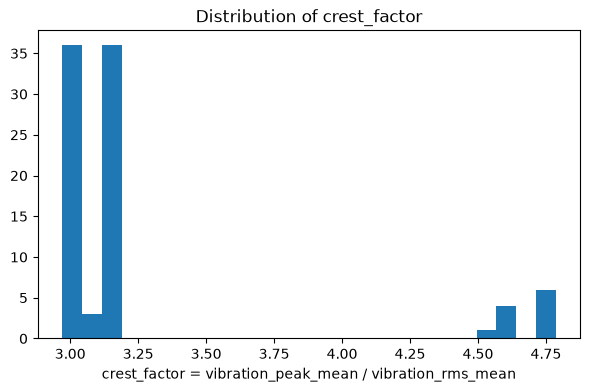

count    86.000000
mean      3.267274
std       0.549097
min       2.971121
25%       2.998382
50%       3.117657
75%       3.122378
max       4.785400
Name: crest_factor, dtype: float64


In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df['crest_factor'], bins=25)
ax.set_xlabel('crest_factor = vibration_peak_mean / vibration_rms_mean')
ax.set_title('Distribution of crest_factor')
plt.show()

print(df['crest_factor'].describe())

We see 11 obvious outliers with `crest_factor > 4.5`.

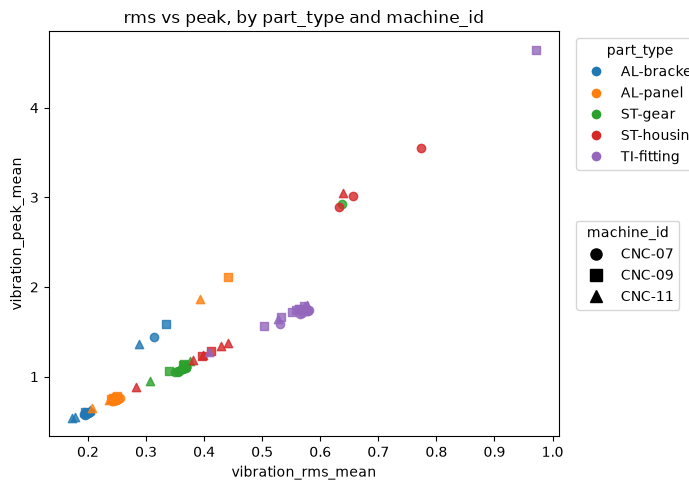

In [15]:
part_types = sorted(df['part_type'].unique())
machine_ids = sorted(df['machine_id'].unique())
color_map = dict(zip(part_types, plt.cm.tab10.colors))
marker_map = dict(zip(machine_ids, ['o', 's', '^', 'D', 'v', 'P', 'X']))

fig, ax = plt.subplots(figsize=(7, 5))
for (pt, m), sub in df.groupby(['part_type', 'machine_id']):
    ax.scatter(sub['vibration_rms_mean'], sub['vibration_peak_mean'],
               color=color_map[pt], marker=marker_map[m], alpha=0.8)

ax.set_xlabel('vibration_rms_mean')
ax.set_ylabel('vibration_peak_mean')
ax.set_title('rms vs peak, by part_type and machine_id')

color_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, label=pt, markersize=8)
                  for pt, c in color_map.items()]
marker_handles = [Line2D([0], [0], marker=mk, color='black', linestyle='', label=m, markersize=8)
                    for m, mk in marker_map.items()]
leg1 = ax.legend(handles=color_handles, title='part_type', loc='upper left', bbox_to_anchor=(1.02, 1))
ax.add_artist(leg1)
ax.legend(handles=marker_handles, title='machine_id', loc='upper left', bbox_to_anchor=(1.02, 0.55))
plt.tight_layout()
plt.show()

We see not one clean line but two, which lines up with the bimodal `crest_factor`
distribution. Also, both "lines" on the plot contain a mix of `part_type` and
`machine_id` — so the groups aren't the explanation here, this is an independent signal.

In [16]:
crest_outliers = df[df['crest_factor'] > 4.5].sort_values('crest_factor', ascending=False)
print(f"{len(crest_outliers)} jobs with crest_factor > 4.5")
crest_outliers[['job_id', 'machine_id', 'part_type', 'vibration_rms_mean', 'vibration_peak_mean', 'crest_factor']]

11 jobs with crest_factor > 4.5


,job_id,machine_id,part_type,vibration_rms_mean,vibration_peak_mean,crest_factor
58,JOB-120,CNC-09,AL-panel,0.441638,2.113416,4.785400
44,JOB-104,CNC-09,TI-fitting,0.971477,4.647305,4.783752
68,JOB-206,CNC-11,ST-housing,0.639892,3.048673,4.764351
46,JOB-106,CNC-09,AL-bracket,0.333829,1.588701,4.759034
85,JOB-224,CNC-11,AL-panel,0.392885,1.866238,4.750094
72,JOB-210,CNC-11,AL-bracket,0.288360,1.361997,4.723249
23,JOB-024,CNC-07,ST-gear,0.636788,2.926735,4.596089
35,JOB-040,CNC-07,ST-housing,0.656336,3.015194,4.593982
6,JOB-007,CNC-07,ST-housing,0.773066,3.550886,4.593252
17,JOB-018,CNC-07,AL-bracket,0.313917,1.439228,4.584736


It's not yet clear whether these are outliers (artifact/noise) or a real signal (e.g.
wear). We temporarily exclude these jobs and check how strongly `rms` and `peak`
correlate on the rest.

In [17]:
crest_outlier_ids = set(crest_outliers['job_id'])
df_no_crest_outliers = df[~df['job_id'].isin(crest_outlier_ids)]

corr_all = df['vibration_rms_mean'].corr(df['vibration_peak_mean'])
corr_clean = df_no_crest_outliers['vibration_rms_mean'].corr(df_no_crest_outliers['vibration_peak_mean'])
print(f"corr(rms, peak) on all {len(df)} jobs: {corr_all:.3f}")
print(f"corr(rms, peak) excluding the {len(crest_outlier_ids)} crest outliers: {corr_clean:.3f}")

corr(rms, peak) on all 86 jobs: 0.932
corr(rms, peak) excluding the 11 crest outliers: 0.998


The correlation is very high either way. So for further analysis either vibration
quantity can be used; we'll take `vibration_peak_mean`, since it matches the "chatter"
framing in the README more directly.

## 2. Relationship between `vibration_peak_mean` and `power_kw_mean`

Obviously, if we only look at vibration, high values could be caused not so much by wear
as by the hardness of the material being machined. So it may matter to look at vibration
together with power. We'll build a linear regression model relating `power_kw_mean` to
`vibration_peak_mean`, and treat jobs that deviate strongly from the regression line as
wear.

Plan:
1. Scatter `power_kw_mean` vs `vibration_peak_mean` (by group) + a regression line over
   all the data — visually a strong linear relationship.
2. Mark the 11 jobs with `crest_factor > 4.5` from part 1 on this plot with red crosses
   — check that these are indeed the visual outliers, and nothing else is left over.
3. Confirm that the top jobs by regression residual are exactly these same 11, with a
   clear gap from everything else.
4. Exclude them, refit the regression — the final coefficient.
5. Check what automatic threshold on the deviation from the line would catch these
   outliers.

Since there isn't much data, we won't use a train/test split and will compute RMSE on
all the data.

OLS on all 86 jobs: peak = 0.1160 * power + 0.2293


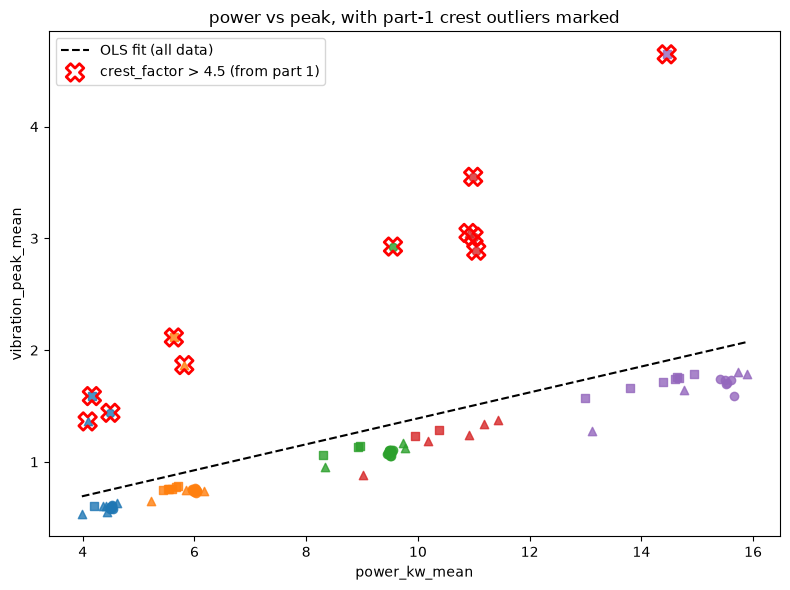

In [18]:
def ols_1d(x, y):
    slope, intercept = np.polyfit(x, y, 1)
    return slope, intercept

slope_all, intercept_all = ols_1d(df['power_kw_mean'], df['vibration_peak_mean'])
print(f"OLS on all {len(df)} jobs: peak = {slope_all:.4f} * power + {intercept_all:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
for (pt, m), sub in df.groupby(['part_type', 'machine_id']):
    ax.scatter(sub['power_kw_mean'], sub['vibration_peak_mean'],
               color=color_map[pt], marker=marker_map[m], alpha=0.8)

xs_line = np.linspace(df['power_kw_mean'].min(), df['power_kw_mean'].max(), 100)
ax.plot(xs_line, slope_all * xs_line + intercept_all, color='black', linestyle='--', label='OLS fit (all data)')

mark_df = df[df['job_id'].isin(crest_outlier_ids)]
ax.scatter(mark_df['power_kw_mean'], mark_df['vibration_peak_mean'],
           facecolors='none', edgecolors='red', marker='X', s=160, linewidths=2,
           label='crest_factor > 4.5 (from part 1)')

ax.set_xlabel('power_kw_mean')
ax.set_ylabel('vibration_peak_mean')
ax.set_title('power vs peak, with part-1 crest outliers marked')
ax.legend()
plt.tight_layout()
plt.show()

Now (after cleaning `power_kw`) the red crosses visually are all the deviations from
the line — no leftover points are visible. Let's confirm this explicitly via the
regression residuals: take the top jobs by residual and check whether it matches
exactly the 11 jobs from part 1.

In [19]:
df['resid_all_fit'] = df['vibration_peak_mean'] - (slope_all * df['power_kw_mean'] + intercept_all)

n_outliers = len(crest_outlier_ids)
top_by_resid = df.sort_values('resid_all_fit', ascending=False)
top_ids = set(top_by_resid['job_id'].head(n_outliers))

print(f"top {n_outliers} jobs by regression residual match the crest_factor>4.5 list exactly: "
      f"{top_ids == crest_outlier_ids}")
print()
print(f"gap between rank {n_outliers} and rank {n_outliers + 1} residuals: "
      f"{top_by_resid['resid_all_fit'].iloc[n_outliers - 1] - top_by_resid['resid_all_fit'].iloc[n_outliers]:.4f}")

top_by_resid[['job_id', 'machine_id', 'part_type', 'power_kw_mean', 'vibration_peak_mean', 'resid_all_fit']].head(n_outliers + 4)

top 11 jobs by regression residual match the crest_factor>4.5 list exactly: True

gap between rank 11 and rank 12 residuals: 0.7683


,job_id,machine_id,part_type,power_kw_mean,vibration_peak_mean,resid_all_fit
44,JOB-104,CNC-09,TI-fitting,14.453782,4.647305,2.741136
6,JOB-007,CNC-07,ST-housing,10.989231,3.550886,2.046655
23,JOB-024,CNC-07,ST-gear,9.553492,2.926735,1.589071
68,JOB-206,CNC-11,ST-housing,10.905508,3.048673,1.554155
35,JOB-040,CNC-07,ST-housing,10.996233,3.015194,1.510150
27,JOB-032,CNC-07,ST-housing,11.043879,2.889669,1.379098
58,JOB-120,CNC-09,AL-panel,5.631079,2.113416,1.230809
85,JOB-224,CNC-11,AL-panel,5.817582,1.866238,0.961994
46,JOB-106,CNC-09,AL-bracket,4.163530,1.588701,0.876351
17,JOB-018,CNC-07,AL-bracket,4.495357,1.439228,0.688381


In [20]:
outlier_ids = crest_outlier_ids
print(f"final outlier list: {len(outlier_ids)} jobs")

df['is_outlier'] = df['job_id'].isin(outlier_ids)
clean = df[~df['is_outlier']]

slope_clean, intercept_clean = ols_1d(clean['power_kw_mean'], clean['vibration_peak_mean'])
print(f"regression on clean data ({len(clean)} jobs): peak = {slope_clean:.4f} * power + {intercept_clean:.4f}")

df['wear_residual'] = df['vibration_peak_mean'] - (slope_clean * df['power_kw_mean'] + intercept_clean)

final outlier list: 11 jobs
regression on clean data (75 jobs): peak = 0.1046 * power + 0.1275


Let's visually compare the two lines: the one fit on all the data (used only to
visually spot outliers), and the one fit without the 11 outliers (`slope_clean`/
`intercept_clean`) — `wear_residual` and the outlier threshold below are computed
relative to the **second** line.

fit on all 86 jobs:            peak = 0.1160 * power + 0.2293
fit on 75 jobs (no outliers): peak = 0.1046 * power + 0.1275


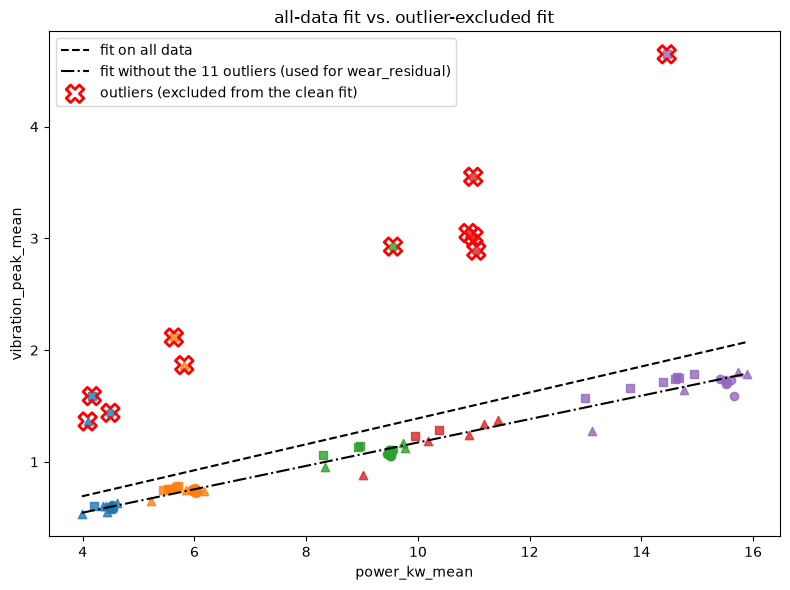

In [21]:
print(f"fit on all {len(df)} jobs:            peak = {slope_all:.4f} * power + {intercept_all:.4f}")
print(f"fit on {len(clean)} jobs (no outliers): peak = {slope_clean:.4f} * power + {intercept_clean:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
for (pt, m), sub in df.groupby(['part_type', 'machine_id']):
    ax.scatter(sub['power_kw_mean'], sub['vibration_peak_mean'],
               color=color_map[pt], marker=marker_map[m], alpha=0.8)

xs_line = np.linspace(df['power_kw_mean'].min(), df['power_kw_mean'].max(), 100)
ax.plot(xs_line, slope_all * xs_line + intercept_all, color='black', linestyle='--',
        label='fit on all data')
ax.plot(xs_line, slope_clean * xs_line + intercept_clean, color='black', linestyle='-.',
        label='fit without the 11 outliers (used for wear_residual)')

outlier_df = df[df['is_outlier']]
ax.scatter(outlier_df['power_kw_mean'], outlier_df['vibration_peak_mean'],
           facecolors='none', edgecolors='red', marker='X', s=160, linewidths=2,
           label='outliers (excluded from the clean fit)')

ax.set_xlabel('power_kw_mean')
ax.set_ylabel('vibration_peak_mean')
ax.set_title('all-data fit vs. outlier-excluded fit')
ax.legend()
plt.tight_layout()
plt.show()

Let's check whether a single overall threshold on `|wear_residual|` can automatically
catch all 11 outliers.

In [22]:
def otsu_threshold(values):
    """
    1D Otsu threshold: pick the split maximizing between-group variance --
    more robust than "largest adjacent gap" when the outlier cluster itself
    has internal spread.
    """
    v = np.sort(np.asarray(values))
    n = len(v)
    best_t, best_score = None, -np.inf
    for i in range(1, n):
        left, right = v[:i], v[i:]
        wl, wr = i / n, (n - i) / n
        score = wl * wr * (left.mean() - right.mean()) ** 2
        if score > best_score:
            best_score, best_t = score, (v[i - 2] + v[i - 1]) / 2
    return best_t


auto_threshold = otsu_threshold(df['wear_residual'].abs())
auto_flagged = set(df.loc[df['wear_residual'].abs() > auto_threshold, 'job_id'])

print(f"Otsu threshold on |wear_residual|: {auto_threshold:.4f}")
print(f"auto-flagged: {len(auto_flagged)} jobs")
print(f"matches the manual {len(outlier_ids)}-job list exactly: {auto_flagged == outlier_ids}")
print(f"missing from auto-detection: {sorted(outlier_ids - auto_flagged)}")

Otsu threshold on |wear_residual|: 0.8242
auto-flagged: 10 jobs
matches the manual 11-job list exactly: False
missing from auto-detection: ['JOB-210']


The automatic threshold on the absolute residual still doesn't catch them all — it
misses exactly the lower-power jobs (`AL-bracket`), where even a strong relative
deviation gives a small absolute residual (heteroscedasticity: the residual spread
grows with the power/vibration level). So we fix the final outlier list by
`crest_factor` (part 1), which stays reliable in this case too, rather than by a single
mechanical formula on the regression residuals.

Another way to pick the threshold — in the spirit of SVM: take the midpoint between the
`wear_residual` of the nearest of the 11 known outliers and the `wear_residual` of the
farthest normal job — the largest margin separating the two classes.

In [23]:
nearest_outlier_residual = df.loc[df['is_outlier'], 'wear_residual'].min()
farthest_normal_residual = df.loc[~df['is_outlier'], 'wear_residual'].max()
svm_style_threshold = (nearest_outlier_residual + farthest_normal_residual) / 2

svm_flagged = set(df.loc[df['wear_residual'] > svm_style_threshold, 'job_id'])

print(f"nearest outlier's wear_residual (the 'support vector'): {nearest_outlier_residual:.4f}")
print(f"farthest normal job's wear_residual:                    {farthest_normal_residual:.4f}")
print(f"margin between the two classes:                         {nearest_outlier_residual - farthest_normal_residual:.4f}")
print(f"SVM-style threshold (midpoint of the margin):           {svm_style_threshold:.4f}")
print()
print(f"flagged: {len(svm_flagged)} jobs, matches the manual {len(outlier_ids)}-job list exactly: {svm_flagged == outlier_ids}")

# Same idea, but relative to the predicted value instead of an absolute amount of g --
# this is what analyze.py actually uses as wear_score, since the absolute version's
# scale grows with power (see the Otsu threshold above missing JOB-210).
predicted_clean = slope_clean * df['power_kw_mean'] + intercept_clean
df['wear_residual_rel'] = df['wear_residual'] / predicted_clean

nearest_outlier_residual_rel = df.loc[df['is_outlier'], 'wear_residual_rel'].min()
farthest_normal_residual_rel = df.loc[~df['is_outlier'], 'wear_residual_rel'].max()
svm_style_threshold_rel = (nearest_outlier_residual_rel + farthest_normal_residual_rel) / 2

rel_flagged = set(df.loc[df['wear_residual_rel'] > svm_style_threshold_rel, 'job_id'])

print()
print(f"relative SVM-style threshold (midpoint of the margin): {svm_style_threshold_rel:.4f}")
print(f"flagged: {len(rel_flagged)} jobs, matches the manual {len(outlier_ids)}-job list exactly: {rel_flagged == outlier_ids}")

nearest outlier's wear_residual (the 'support vector'): 0.8069
farthest normal job's wear_residual:                    0.0986
margin between the two classes:                         0.7083
SVM-style threshold (midpoint of the margin):           0.4527

flagged: 11 jobs, matches the manual 11-job list exactly: True

relative SVM-style threshold (midpoint of the margin): 0.6652
flagged: 11 jobs, matches the manual 11-job list exactly: True


In [24]:
df[df['is_outlier']][
    ['job_id', 'machine_id', 'part_type', 'power_kw_mean', 'vibration_peak_mean',
     'crest_factor', 'wear_residual', 'wear_residual_rel']
].sort_values('wear_residual_rel', ascending=False)

,job_id,machine_id,part_type,power_kw_mean,vibration_peak_mean,crest_factor,wear_residual,wear_residual_rel
58,JOB-120,CNC-09,AL-panel,5.631079,2.113416,4.785400,1.396806,1.949186
44,JOB-104,CNC-09,TI-fitting,14.453782,4.647305,4.783752,3.007721,1.834440
46,JOB-106,CNC-09,AL-bracket,4.163530,1.588701,4.759034,1.025617,1.821428
6,JOB-007,CNC-07,ST-housing,10.989231,3.550886,4.593252,2.273740,1.780330
23,JOB-024,CNC-07,ST-gear,9.553492,2.926735,4.596089,1.799787,1.597046
85,JOB-224,CNC-11,AL-panel,5.817582,1.866238,4.750094,1.130118,1.535234
72,JOB-210,CNC-11,AL-bracket,4.087395,1.361997,4.723249,0.806877,1.453520
17,JOB-018,CNC-07,AL-bracket,4.495357,1.439228,4.584736,0.841430,1.407550
68,JOB-206,CNC-11,ST-housing,10.905508,3.048673,4.764351,1.780286,1.403583
35,JOB-040,CNC-07,ST-housing,10.996233,3.015194,4.593982,1.737316,1.359532


Note that these same 11 jobs could also have been caught using `crest_factor` from
part 1.

## 3. Do `part_type` and `machine_id` strengthen the model?

By eye, the plot from part 2 doesn't look like it depends on `machine_id`, but the
`part_type` data is grouped and may have an effect on the model. Let's add `part_type`
and `machine_id` as factors in the regression (on the outlier-free data) and look at
the coefficients.

In [25]:
def fit_with_groups(data):
    X_parts = pd.get_dummies(data['part_type'], prefix='part', drop_first=True)
    X_mach = pd.get_dummies(data['machine_id'], prefix='machine', drop_first=True)
    X = pd.concat([
        pd.Series(1.0, index=data.index, name='intercept'),
        data['power_kw_mean'],
        X_parts,
        X_mach,
    ], axis=1)
    beta, *_ = np.linalg.lstsq(X.to_numpy(dtype=float), data['vibration_peak_mean'].to_numpy(dtype=float), rcond=None)
    pred = X.to_numpy(dtype=float) @ beta
    resid = data['vibration_peak_mean'].to_numpy() - pred
    rmse = np.sqrt((resid ** 2).mean())
    return pd.Series(beta, index=X.columns), rmse


beta_grouped, rmse_grouped = fit_with_groups(clean)

resid_simple = clean['vibration_peak_mean'] - (slope_clean * clean['power_kw_mean'] + intercept_clean)
rmse_simple = np.sqrt((resid_simple ** 2).mean())

print(beta_grouped)
print()
print(f"RMSE, simple model (power only): {rmse_simple:.4f}")
print(f"RMSE, grouped model (power + part_type + machine_id): {rmse_grouped:.4f}")

intercept         -0.087487
power_kw_mean      0.149666
part_AL-panel     -0.085324
part_ST-gear      -0.244136
part_ST-housing   -0.302061
part_TI-fitting   -0.507246
machine_CNC-09     0.132605
machine_CNC-11     0.016073
dtype: float64

RMSE, simple model (power only): 0.0589
RMSE, grouped model (power + part_type + machine_id): 0.0360


Indeed, the `machine_id` coefficients (CNC-09/CNC-11) are small — the machine barely
matters. `part_type`, on the other hand, matters noticeably: for example, `TI-fitting`
gives a substantially different `peak` level for the same `power`, which makes physical
sense — different materials cut differently — and adding `part_type` to the model
lowers the RMSE. So `machine_id` can be left out, while `part_type`, strictly speaking,
would be worth including in the model for a more sensitive `wear_residual`. But since
both the simple and the grouped model find the same set of 11 jobs as the strongest
outliers (see part 2), we'll use the already-computed simple `wear_residual` for the
final analysis below.

## 4. Are these outliers really wear?

Let's plot `wear_residual` over time for each machine — the x-axis is the job's start
time (`start_time`). This lets us see the time gaps between jobs. Outliers (the list
from part 2) are marked with red crosses.

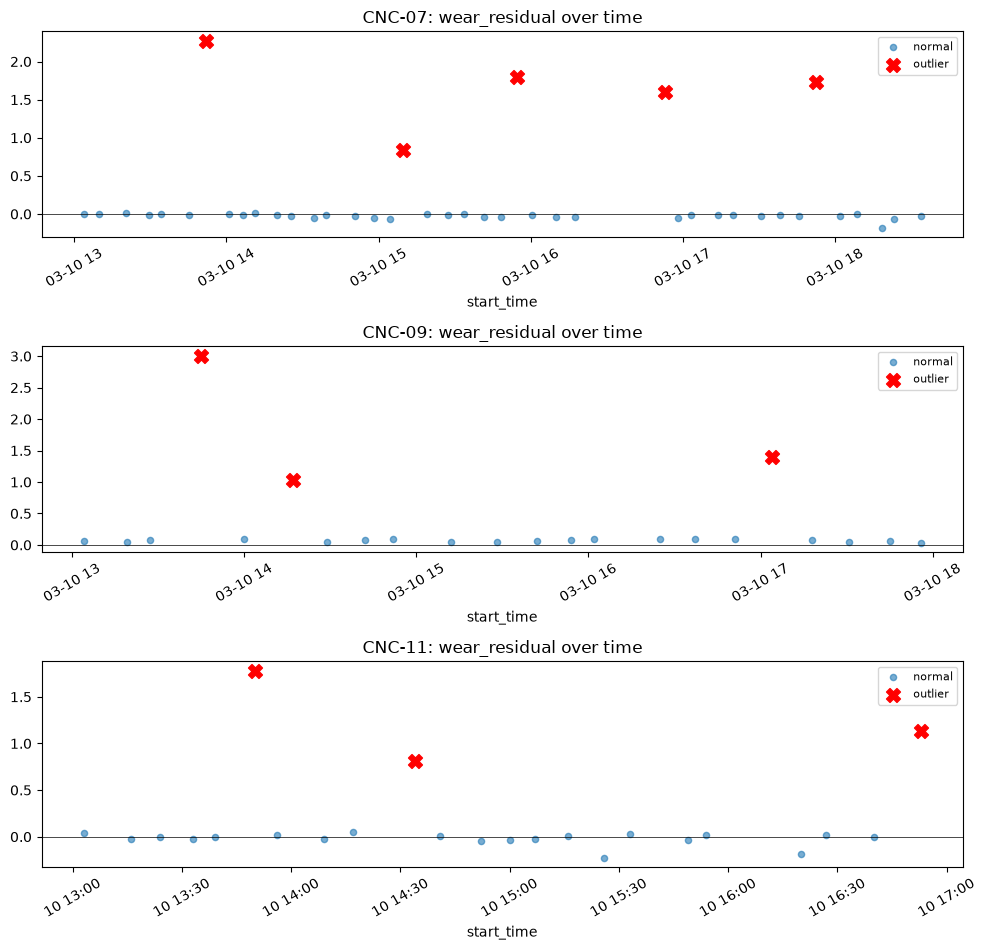

In [26]:
fig, axes = plt.subplots(len(machine_ids), 1, figsize=(10, 3.2 * len(machine_ids)), squeeze=False)

for row, m in enumerate(machine_ids):
    sub = df[df['machine_id'] == m].sort_values('start_time')
    normal = sub[~sub['is_outlier']]
    outliers = sub[sub['is_outlier']]

    ax = axes[row, 0]
    ax.scatter(normal['start_time'], normal['wear_residual'], s=20, alpha=0.6, label='normal')
    ax.scatter(outliers['start_time'], outliers['wear_residual'], s=100, color='red', marker='X', label='outlier')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(f'{m}: wear_residual over time')
    ax.set_xlabel('start_time')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

On one hand, within the terms of the task, it does look like these outliers really are
wear — they deviate that strongly from the overall dynamics. But two things are
bothering me:
- Wear can't set in suddenly, yet the per-machine plots above show that `wear_residual`
  has no build-up/cumulative effect: the outliers appear abruptly, on a single job.
- With wear, replacing the tool should take some time, but the plots don't show any
  change in the timing of the current/next job around the outliers. Though maybe the
  equipment allows a fast swap, so this counter-argument might not hold.

Given that this data is clearly synthetic, it's possible these considerations simply
weren't accounted for when the data was generated.

In total, we get 11 jobs that can be interpreted as wear.

In [27]:
df[df['is_outlier'] == True].sort_values('wear_residual_rel', ascending=False)[['job_id', 'wear_residual_rel']]

,job_id,wear_residual_rel
58,JOB-120,1.949186
44,JOB-104,1.834440
46,JOB-106,1.821428
6,JOB-007,1.780330
23,JOB-024,1.597046
85,JOB-224,1.535234
72,JOB-210,1.453520
17,JOB-018,1.407550
68,JOB-206,1.403583
35,JOB-040,1.359532
